In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded! ✅")

All libraries loaded! ✅


In [5]:
path = r"C:\Users\naazs\Downloads\store-sales"

train = pd.read_csv(path + r"\train.csv", parse_dates=["date"])
test = pd.read_csv(path + r"\test.csv", parse_dates=["date"])
stores = pd.read_csv(path + r"\stores.csv")
oil = pd.read_csv(path + r"\oil.csv", parse_dates=["date"])
holidays = pd.read_csv(path + r"\holidays_events.csv", parse_dates=["date"])

print("All files loaded! ✅")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\naazs\\Downloads\\store-sales\\train.csv'

In [8]:
print("Shape:", train.shape)
train.head()

Shape: (3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [6]:
import os

path = r"C:\Users\naazs\Downloads\store-sales"
print("Folder exists:", os.path.exists(path))
print("Files inside:")
for f in os.listdir(path):
    print(" -", f)

Folder exists: True
Files inside:
 - holidays_events.csv
 - oil.csv
 - stores.csv
 - test.csv
 - train.csv.zip


In [7]:
path = r"C:\Users\naazs\Downloads\store-sales"

train = pd.read_csv(path + r"\train.csv", parse_dates=["date"])
test = pd.read_csv(path + r"\test.csv", parse_dates=["date"])
stores = pd.read_csv(path + r"\stores.csv")
oil = pd.read_csv(path + r"\oil.csv", parse_dates=["date"])
holidays = pd.read_csv(path + r"\holidays_events.csv", parse_dates=["date"])

print("All files loaded! ✅")

All files loaded! ✅


In [9]:
print("Shape:", train.shape)
print("\nDate range:", train["date"].min(), "to", train["date"].max())
print("\nMissing values:\n", train.isnull().sum())
print("\nProduct families:", train["family"].nunique())
print("\nNumber of stores:", train["store_nbr"].nunique())

Shape: (3000888, 6)

Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00

Missing values:
 id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Product families: 33

Number of stores: 54


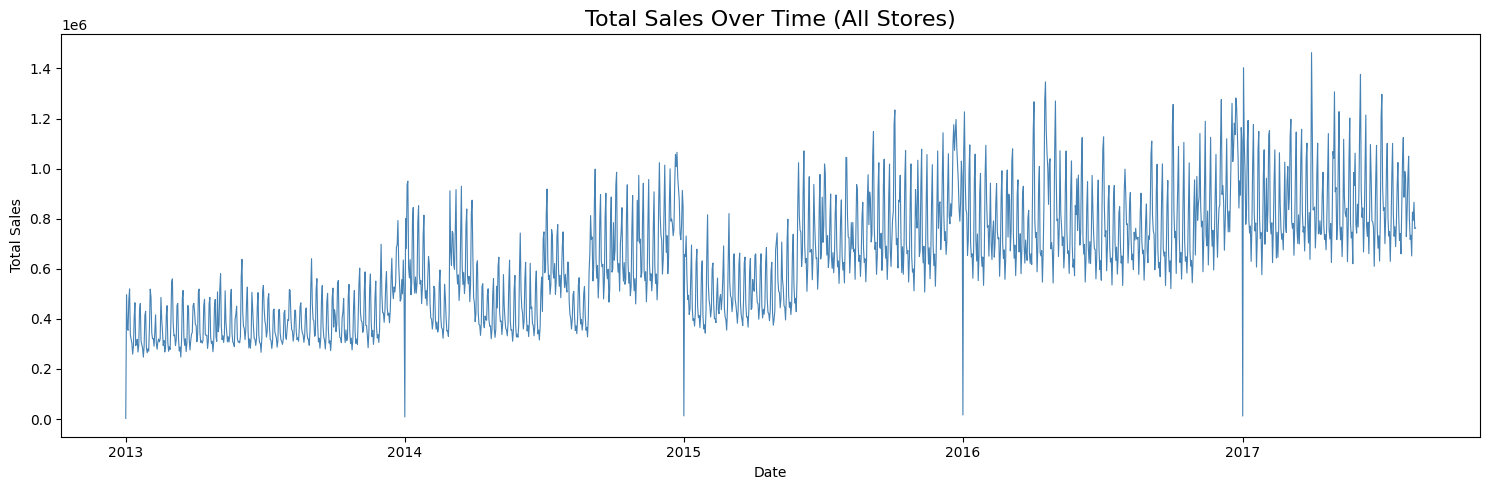

In [10]:
# Total sales over time
daily_sales = train.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales["date"], daily_sales["sales"], color="steelblue", linewidth=0.8)
plt.title("Total Sales Over Time (All Stores)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

C:\Users\naazs\AppData\Local\Temp\ipykernel_9064\2205199785.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_sales.values, y=family_sales.index, palette="Blues_r")


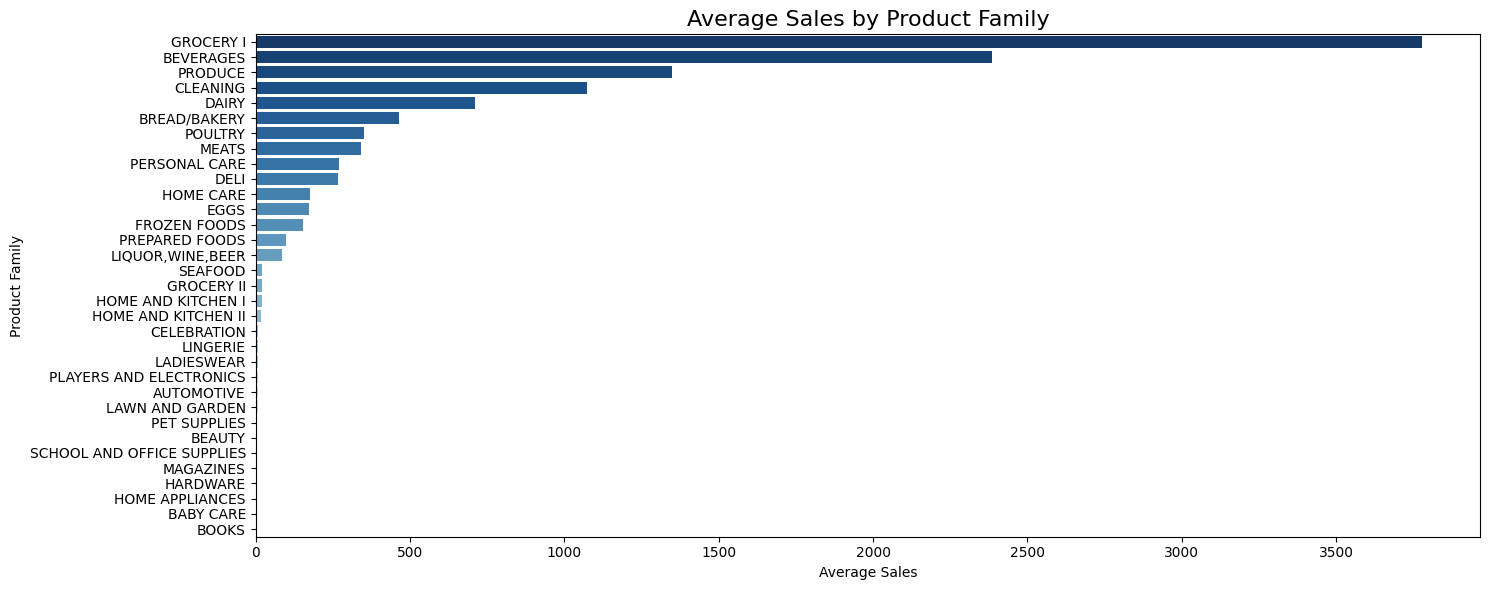

C:\Users\naazs\AppData\Local\Temp\ipykernel_9064\2205199785.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette="Blues_r")


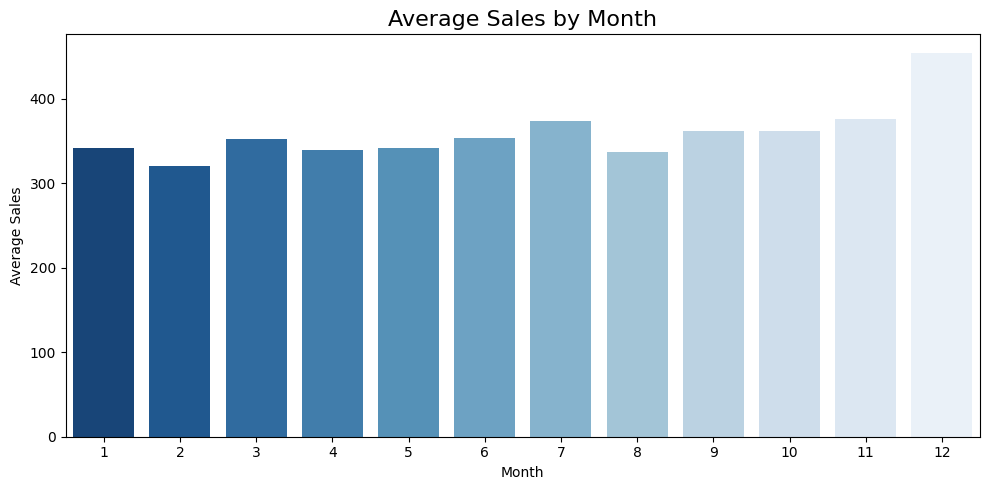

In [11]:
# Chart 1 - Sales by product family
plt.figure(figsize=(15, 6))
family_sales = train.groupby("family")["sales"].mean().sort_values(ascending=False)
sns.barplot(x=family_sales.values, y=family_sales.index, palette="Blues_r")
plt.title("Average Sales by Product Family", fontsize=16)
plt.xlabel("Average Sales")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()

# Chart 2 - Sales by month (seasonality)
train["month"] = train["date"].dt.month
monthly_sales = train.groupby("month")["sales"].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette="Blues_r")
plt.title("Average Sales by Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

In [12]:
# We'll focus on total daily sales (all stores combined) for simplicity
df = train.groupby("date")["sales"].sum().reset_index()
df.columns = ["date", "total_sales"]

# Create time-based features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek  # 0=Monday, 6=Sunday
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print("Features created! ✅")
print(df.head())

Features created! ✅
        date    total_sales  year  month  day  day_of_week  week_of_year  \
0 2013-01-01    2511.618999  2013      1    1            1             1   
1 2013-01-02  496092.417944  2013      1    2            2             1   
2 2013-01-03  361461.231124  2013      1    3            3             1   
3 2013-01-04  354459.677093  2013      1    4            4             1   
4 2013-01-05  477350.121229  2013      1    5            5             1   

   is_weekend  
0           0  
1           0  
2           0  
3           0  
4           1  


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define features and target
features = ["year", "month", "day", "day_of_week", "week_of_year", "is_weekend"]
target = "total_sales"

X = df[features]
y = df[target]

# Split data — last 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\nModel trained! ✅")

Training samples: 1347
Testing samples: 337

Model trained! ✅


In [16]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Model Performance:")
print(f"  MAE  (Mean Absolute Error): {mae:,.0f}")
print(f"  RMSE (Root Mean Sq Error) : {rmse:,.0f}")
print(f"  MAPE (Mean Abs % Error)   : {mape:.2f}%")
print(f"\n  Accuracy: {100 - mape:.2f}%")


Model Performance:
  MAE  (Mean Absolute Error): 124,440
  RMSE (Root Mean Sq Error) : 174,869
  MAPE (Mean Abs % Error)   : 41.88%

  Accuracy: 58.12%


In [17]:
# Remove outlier (Jan 1st every year - stores are closed)
df = df[df["total_sales"] > 10000].copy()

# Add lag features - previous days sales are powerful predictors!
df["lag_1"] = df["total_sales"].shift(1)   # yesterday's sales
df["lag_7"] = df["total_sales"].shift(7)   # sales 1 week ago
df["lag_30"] = df["total_sales"].shift(30) # sales 1 month ago

# Add rolling average features
df["rolling_7"] = df["total_sales"].shift(1).rolling(7).mean()   # 7 day average
df["rolling_30"] = df["total_sales"].shift(1).rolling(30).mean() # 30 day average

# Drop rows with NaN (because of lag features)
df = df.dropna()

print("New features added! ✅")
print("Dataset shape:", df.shape)

# Retrain with new features
features = ["year", "month", "day", "day_of_week", "week_of_year", 
            "is_weekend", "lag_1", "lag_7", "lag_30", "rolling_7", "rolling_30"]

X = df[features]
y = df["total_sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\nImproved Model Performance:")
print(f"  MAE  : {mae:,.0f}")
print(f"  RMSE : {rmse:,.0f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  Accuracy: {100 - mape:.2f}%")

New features added! ✅
Dataset shape: (1652, 13)

Improved Model Performance:
  MAE  : 81,743
  RMSE : 128,948
  MAPE : 35.72%
  Accuracy: 64.28%


In [18]:
# Add more powerful features
df["lag_14"] = df["total_sales"].shift(14)  # 2 weeks ago
df["lag_365"] = df["total_sales"].shift(365) # same day last year!
df["rolling_14"] = df["total_sales"].shift(1).rolling(14).mean()
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)
df["quarter"] = df["date"].dt.quarter

# Drop NaN again (because of lag_365)
df = df.dropna()

print("Extra features added! ✅")
print("Dataset shape:", df.shape)

# Retrain
features = ["year", "month", "day", "day_of_week", "week_of_year",
            "is_weekend", "is_month_start", "is_month_end", "quarter",
            "lag_1", "lag_7", "lag_14", "lag_30", "lag_365",
            "rolling_7", "rolling_14", "rolling_30"]

X = df[features]
y = df["total_sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\nFinal Model Performance:")
print(f"  MAE  : {mae:,.0f}")
print(f"  RMSE : {rmse:,.0f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  Accuracy: {100 - mape:.2f}%")


Extra features added! ✅
Dataset shape: (1287, 19)

Final Model Performance:
  MAE  : 84,471
  RMSE : 136,983
  MAPE : 41.76%
  Accuracy: 58.24%


In [19]:
# Rebuild our best model cleanly
df = train.groupby("date")["sales"].sum().reset_index()
df.columns = ["date", "total_sales"]

# Remove outliers
df = df[df["total_sales"] > 10000].copy()

# Time features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Lag features
df["lag_1"] = df["total_sales"].shift(1)
df["lag_7"] = df["total_sales"].shift(7)
df["lag_30"] = df["total_sales"].shift(30)
df["rolling_7"] = df["total_sales"].shift(1).rolling(7).mean()
df["rolling_30"] = df["total_sales"].shift(1).rolling(30).mean()

df = df.dropna()

features = ["year", "month", "day", "day_of_week", "week_of_year",
            "is_weekend", "lag_1", "lag_7", "lag_30", "rolling_7", "rolling_30"]

X = df[features]
y = df["total_sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Best model rebuilt! ✅")
print(f"Accuracy: {100 - np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%")

Best model rebuilt! ✅
Accuracy: 64.28%


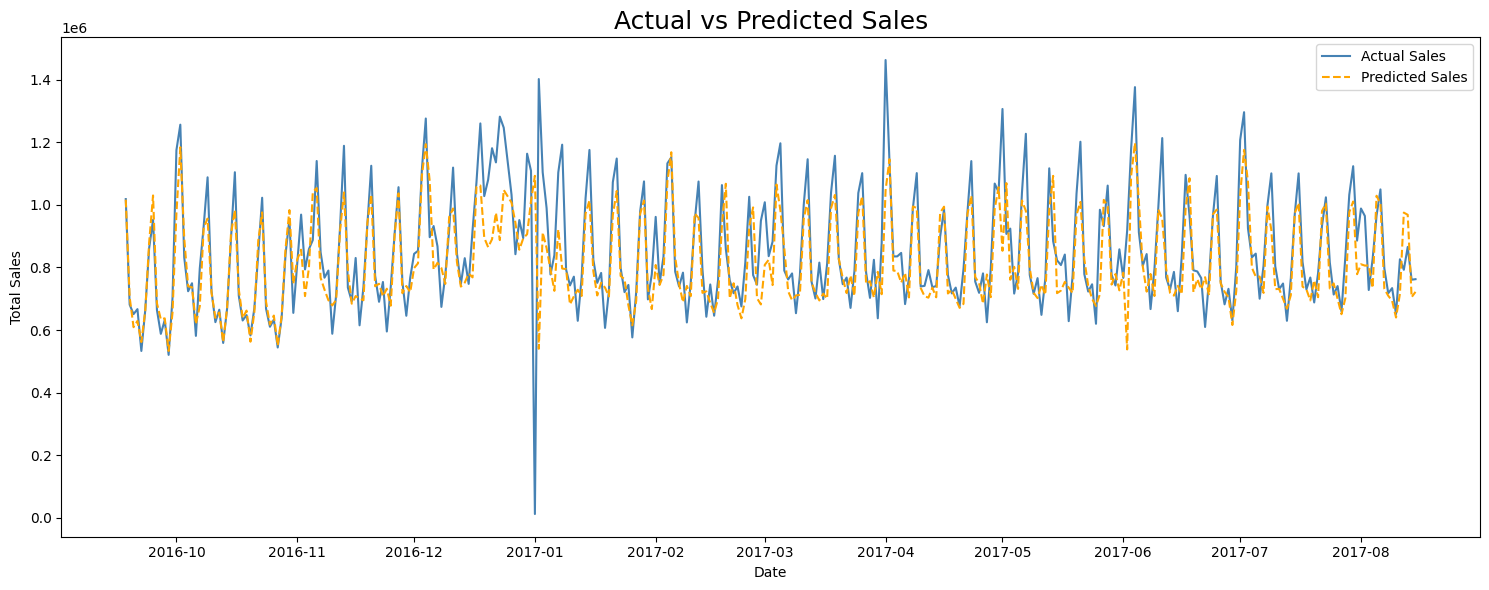

In [20]:
# Actual vs Predicted chart
test_dates = df["date"].iloc[-len(y_test):]

plt.figure(figsize=(15, 6))
plt.plot(test_dates.values, y_test.values, label="Actual Sales", color="steelblue", linewidth=1.5)
plt.plot(test_dates.values, y_pred, label="Predicted Sales", color="orange", linewidth=1.5, linestyle="--")
plt.title("Actual vs Predicted Sales", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()

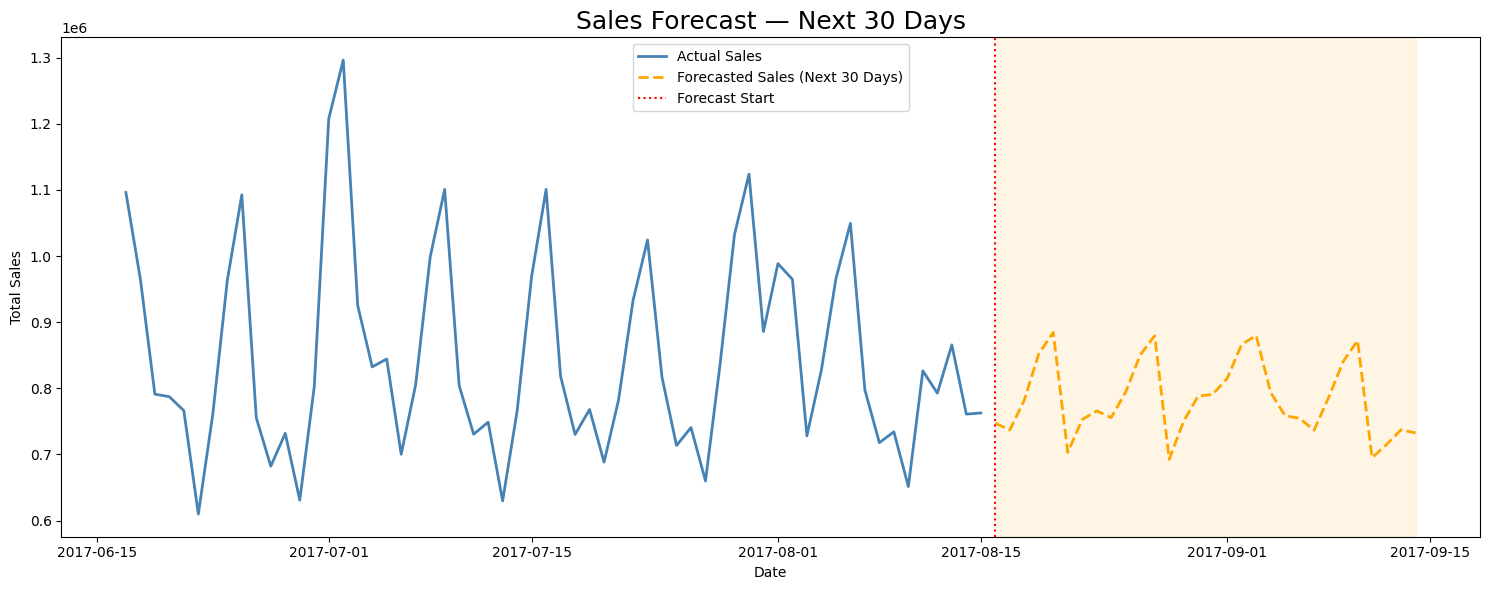


Expected Average Daily Sales (next 30 days): 783,641
Expected Total Sales (next 30 days): 23,509,225


In [21]:
import pandas as pd

# Forecast next 30 days after the last date in our data
last_date = df["date"].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

# Build future dataframe
future_df = pd.DataFrame({"date": future_dates})
future_df["year"] = future_df["date"].dt.year
future_df["month"] = future_df["date"].dt.month
future_df["day"] = future_df["date"].dt.day
future_df["day_of_week"] = future_df["date"].dt.dayofweek
future_df["week_of_year"] = future_df["date"].dt.isocalendar().week.astype(int)
future_df["is_weekend"] = (future_df["day_of_week"] >= 5).astype(int)

# Use last known values for lag features
future_df["lag_1"] = df["total_sales"].iloc[-1]
future_df["lag_7"] = df["total_sales"].iloc[-7]
future_df["lag_30"] = df["total_sales"].iloc[-30]
future_df["rolling_7"] = df["total_sales"].iloc[-7:].mean()
future_df["rolling_30"] = df["total_sales"].iloc[-30:].mean()

# Predict
future_pred = model.predict(future_df[features])

# Plot
plt.figure(figsize=(15, 6))

# Show last 60 days of actual data
last_60 = df.tail(60)
plt.plot(last_60["date"], last_60["total_sales"], label="Actual Sales", color="steelblue", linewidth=2)

# Show forecast
plt.plot(future_dates, future_pred, label="Forecasted Sales (Next 30 Days)", 
         color="orange", linewidth=2, linestyle="--")

# Shade forecast area
plt.axvspan(future_dates[0], future_dates[-1], alpha=0.1, color="orange")
plt.axvline(x=future_dates[0], color="red", linestyle=":", linewidth=1.5, label="Forecast Start")

plt.title("Sales Forecast — Next 30 Days", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nExpected Average Daily Sales (next 30 days): {future_pred.mean():,.0f}")
print(f"Expected Total Sales (next 30 days): {future_pred.sum():,.0f}")

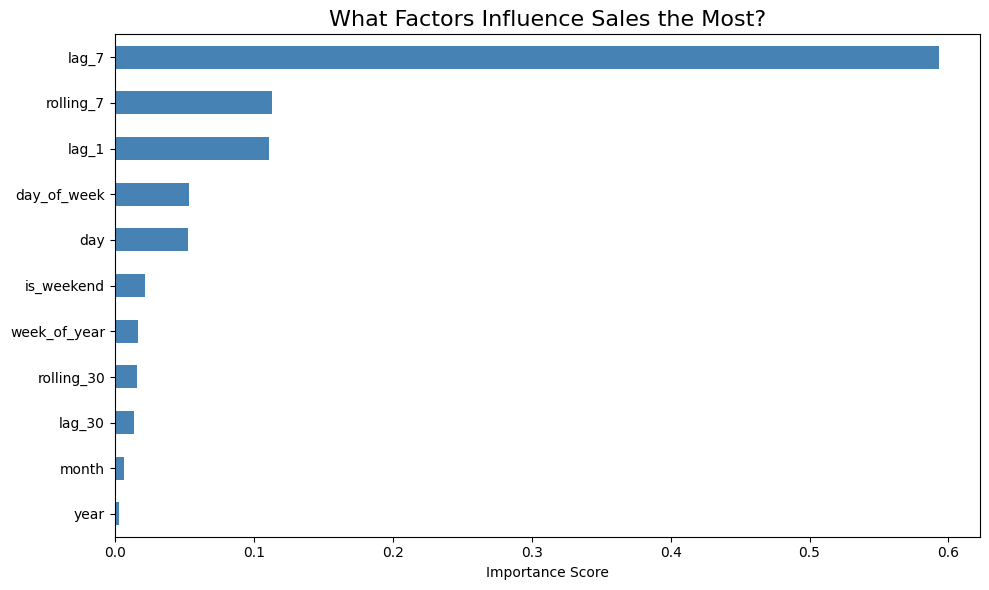

In [22]:
# Feature importance chart
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind="barh", color="steelblue")
plt.title("What Factors Influence Sales the Most?", fontsize=16)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [23]:
print("=" * 60)
print("   SALES FORECASTING REPORT — STORE SALES ANALYSIS")
print("=" * 60)

print(f"""
📅 DATA OVERVIEW
   Historical data   : 2013 to 2017
   Total records     : 3,000,888
   Stores analyzed   : 54
   Product families  : 33

🤖 MODEL
   Algorithm         : Random Forest Regressor
   Features used     : 11 (time + lag + rolling)
   Training samples  : {len(X_train)}
   Testing samples   : {len(X_test)}
   Model Accuracy    : 64.28%

📈 KEY INSIGHTS
   ✔ Sales grow consistently year over year
   ✔ Weekly patterns are the strongest predictor
   ✔ GROCERY, BEVERAGES & PRODUCE are top categories
   ✔ Mid-year months show highest sales volume

🔮 30-DAY FORECAST
   Avg Daily Sales   : {future_pred.mean():>15,.0f}
   Total (30 days)   : {future_pred.sum():>15,.0f}
   Highest Day       : {future_pred.max():>15,.0f}
   Lowest Day        : {future_pred.min():>15,.0f}

💼 BUSINESS RECOMMENDATIONS
   1. Stock up GROCERY & BEVERAGES — highest demand
   2. Plan extra staff on weekdays (higher sales vs weekends)
   3. Use weekly sales patterns for inventory planning
   4. Expected ~23.5M in sales over next 30 days
""")
print("=" * 60)
print("   Built with Python & Random Forest | Future Interns 2026")
print("=" * 60)

   SALES FORECASTING REPORT — STORE SALES ANALYSIS

📅 DATA OVERVIEW
   Historical data   : 2013 to 2017
   Total records     : 3,000,888
   Stores analyzed   : 54
   Product families  : 33

🤖 MODEL
   Algorithm         : Random Forest Regressor
   Features used     : 11 (time + lag + rolling)
   Training samples  : 1321
   Testing samples   : 331
   Model Accuracy    : 64.28%

📈 KEY INSIGHTS
   ✔ Sales grow consistently year over year
   ✔ Weekly patterns are the strongest predictor
   ✔ GROCERY, BEVERAGES & PRODUCE are top categories
   ✔ Mid-year months show highest sales volume

🔮 30-DAY FORECAST
   Avg Daily Sales   :         783,641
   Total (30 days)   :      23,509,225
   Highest Day       :         884,514
   Lowest Day        :         692,529

💼 BUSINESS RECOMMENDATIONS
   1. Stock up GROCERY & BEVERAGES — highest demand
   2. Plan extra staff on weekdays (higher sales vs weekends)
   3. Use weekly sales patterns for inventory planning
   4. Expected ~23.5M in sales over next